In [74]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2

In [75]:
import os
import cv2

path = r"C:\Users\ACS\Desktop\Road damage detection"

row = []
labels = []

for folders in ["train", "test"]:

    split_path = os.path.join(path, folders)

    for category in ["clean road", "potholes"]:

        category_path = os.path.join(split_path, category)

        for image_file in os.listdir(category_path):

            img_path = os.path.join(category_path, image_file)

            print(img_path)

            image = cv2.imread(img_path)

            if image is None:
                print("Could not read:", img_path)
                continue

            resized = cv2.resize(image, (120, 120))

            row.append(resized)
            labels.append(category)

print("Total images:", len(row))
print("Total labels:", len(labels))

C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (1).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (10).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (100).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (101).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (102).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (103).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (104).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (105).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (106).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (107).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (108).jpg
C:\Users\ACS\Desktop\Road damage detection\train\clean road\Clean_Road 3 (109).jpg
C:\User

In [76]:
row[1].shape

(120, 120, 3)

In [77]:
labels[1],labels[::-1][1]

('clean road', 'potholes')

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [79]:
#converting your images and text labels into a format that a CNN can understand.
encoder=LabelEncoder()
x=np.array(row)
y=encoder.fit_transform(labels)

In [80]:
encoder.classes_

array(['clean road', 'potholes'], dtype='<U10')

In [81]:
x.shape

(1700, 120, 120, 3)

In [82]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=21)
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((1360, 120, 120, 3), (340, 120, 120, 3), (1360,), (340,))

# Architecture

In [83]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout

In [84]:
model=Sequential()

model.add(Conv2D(32,(3,3),input_shape=(120,120,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\ACS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 118, 118, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 59, 59, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 57, 57, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 26, 26, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 13, 13, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 21632)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │       2,769,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,872,641 (10.96 MB)

 Trainable params: 2,872,641 (10.96 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [86]:
model.fit(xtrain,ytrain,epochs=5,validation_data=(xtest,ytest),batch_size=32)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.6654 - loss: 2.6625 - val_accuracy: 0.9000 - val_loss: 0.3697
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - accuracy: 0.8294 - loss: 0.4375 - val_accuracy: 0.8765 - val_loss: 0.2954
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 249ms/step - accuracy: 0.8875 - loss: 0.2828 - val_accuracy: 0.9147 - val_loss: 0.2246
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 0.9235 - loss: 0.2161 - val_accuracy: 0.9441 - val_loss: 0.1555
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step - accuracy: 0.9493 - loss: 0.1432 - val_accuracy: 0.9353 - val_loss: 0.2182


In [14]:
test=cv2.imread(r"C:\Users\ACS\Downloads\damaged_undamaged_buildings\test\undamaged\2 (999).jpg")
res=cv2.resize(test,(120,120))
test_input=res.reshape(-1,120,120,3)/255.0
test_input.shape

(1, 120, 120, 3)

In [87]:
xtrain.shape

(1360, 120, 120, 3)

In [88]:
prob=model.predict(test_input)

if prob[0][0]>0.5:
    print("clean road")
else:
    print("potholes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
clean road


# Data Augumentation

In [108]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [90]:
from keras.preprocessing.image import load_img,img_to_array

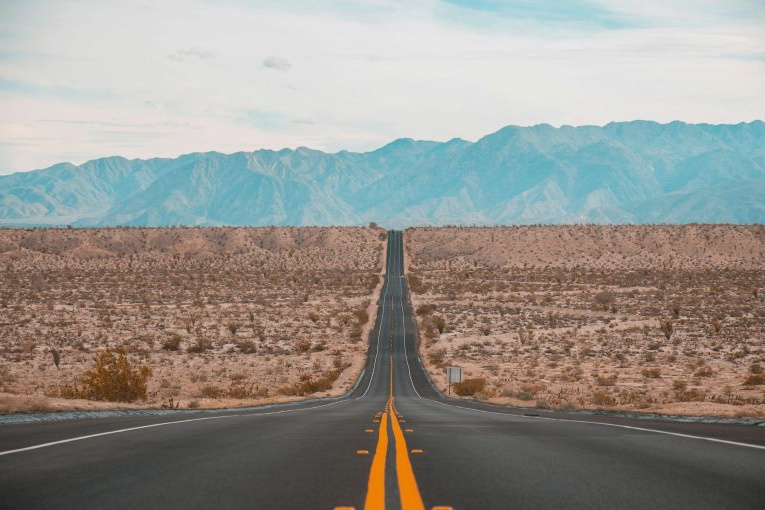

In [91]:
img=load_img(r"C:\Users\ACS\Desktop\Road damage detection\test\Clean road\Clean_Road 3 (1).jpg")
img

In [92]:
img=load_img(r"C:\Users\ACS\Desktop\Road damage detection\test\Clean road\Clean_Road 3 (1).jpg")
array=img_to_array(img)
array

array([[[        169,         183,         186],
        [        169,         183,         186],
        [        170,         183,         189],
        ...,
        [        179,         199,         208],
        [        178,         198,         207],
        [        178,         198,         207]],

       [[        170,         184,         187],
        [        170,         184,         187],
        [        170,         184,         187],
        ...,
        [        178,         198,         207],
        [        177,         197,         206],
        [        177,         197,         206]],

       [[        170,         184,         185],
        [        170,         184,         187],
        [        170,         184,         187],
        ...,
        [        178,         196,         206],
        [        177,         195,         205],
        [        177,         195,         205]],

       ...,

       [[         37,          39,          38],
        [  

In [93]:
datagen=ImageDataGenerator(
    rotation_range=30,# rotation range with degree
    width_shift_range=0.2, #apply the translation invariance
    height_shift_range=0.2, #apply the translation based on height
    zoom_range=0.2, #0-1 range with zoom in or zoom out
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest' #fill the newly generated pixels values with near pixels
)

In [94]:
import os
import numpy as np

from tensorflow.keras.preprocessing.image import load_img, img_to_array

destination_path = r"C:\Users\ACS\Desktop\Road damage detection\new"

image_path = r"C:\Users\ACS\Desktop\Road damage detection\test\Clean road\Clean_Road 3 (52).jpg"

# Create destination folder if it doesn't exist
os.makedirs(destination_path, exist_ok=True)

# Load image and resize to 120x120
img = load_img(
    image_path,
    target_size=(120, 120)
)

# Convert image to NumPy array
array = img_to_array(img)

print("Image shape:", array.shape)

# Normalize pixel values
array = array / 255.0

# Add batch dimension
x = np.expand_dims(array, axis=0)

print("Input shape:", x.shape)

# Generate 100 augmented images
count = 0

for image in datagen.flow(
    x,
    batch_size=1,
    save_to_dir=destination_path,
    save_prefix='damaged',
    save_format='jpg'
):
    count += 1

    if count == 100:
        break

print("100 augmented images created successfully!")

Image shape: (120, 120, 3)
Input shape: (1, 120, 120, 3)
100 augmented images created successfully!


In [95]:
source_path = r"C:\Users\ACS\Desktop\Road damage detection"

destination_path = r"C:\Users\ACS\Desktop\Road damage detection\augumentation_data"

train_gen = datagen.flow_from_directory(
    directory=source_path,
    target_size=(224, 224),
    save_to_dir=destination_path,
    save_prefix="augu",
    save_format="png"
)

Found 2189 images belonging to 4 classes.


# Loading the Pretrained models

In [96]:
from keras.applications import VGG16

# pretrained model for feature extraction

In [97]:
pre_trained=VGG16(include_top=False,weights='imagenet',input_shape=(120,120,3))

In [98]:
pre_trained

<Functional name=vgg16, built=True>

In [99]:
pre_trained.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 120, 120, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 120, 120, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 120, 120, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 60, 60, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 60, 60, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 30, 30, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 15, 15, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 15, 15, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

# create a own fully connected layer

In [100]:
from keras.models import Sequential
from keras.layers import Dense,Flatten,Dropout

In [101]:
model=Sequential()
model.add(pre_trained)
model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [102]:
pre_trained.trainable=False

In [103]:
pre_trained

<Functional name=vgg16, built=True>

In [104]:
pre_trained.output

<KerasTensor shape=(None, 3, 3, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_298>

In [105]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [106]:
model.fit(xtrain,ytrain,epochs=5,validation_data=(xtest,ytest),batch_size=32)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9294 - loss: 0.5565 - val_accuracy: 0.9912 - val_loss: 0.0383
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9941 - loss: 0.0196 - val_accuracy: 1.0000 - val_loss: 7.9982e-04
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9985 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9993 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 5.1322e-05
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 1.0000 - loss: 3.9706e-05 - val_accuracy: 1.0000 - val_loss: 4.4424e-05


In [109]:
import keras
import tensorflow
from keras.applications import VGG16
from keras.layers import Flatten,Dense,Dropout
from keras.models import Sequential

In [110]:
pre_trained=VGG16(include_top=False, # for fine tuning false else true for using the model as it is
                 weights='imagenet',
                 input_shape=(120,120,3))

In [111]:
pre_trained.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 120, 120, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 120, 120, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 120, 120, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 60, 60, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 60, 60, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 30, 30, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 15, 15, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 15, 15, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [112]:
pre_trained.layers

[<InputLayer name=input_layer_8, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [113]:
pre_trained.trainable=True #make all the layers trainable

unfreeze=False  # make few layers non trainable

for layer in pre_trained.layers:
    if layer.name=='block5_conv1': #select only the con5 block for finetuning                               #allows to do changes
        unfreeze=True
    else:
        layer.trainable=unfreeze  #else other layers should not be trainable

for layer in pre_trained.layers:
    print(layer.name,layer.trainable)

input_layer_8 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [114]:
pre_trained.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 120, 120, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 120, 120, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 120, 120, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 60, 60, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 60, 60, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 30, 30, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 15, 15, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 15, 15, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

# fully connected layers

In [115]:
model=Sequential()
model.add(pre_trained)
model.add(Flatten())

model.add(Dense(120,activation='relu'))

model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 3, 3, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 120)                 │         553,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 64)                  │           7,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,275,577 (58.27 MB)

 Trainable params: 7,640,313 (29.15 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

# loading the data using keras functions

In [116]:
import tensorflow as tf
import keras

train=keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\ACS\Desktop\Road damage detection\train",
    labels='inferred', #it is going to take the folder name as class name
    label_mode='int',  #this is going to apply the label encoding
    image_size=(120,120),
    
)

test=keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\ACS\Desktop\Road damage detection\test",
    labels='inferred', #it is going to take the folder name as class name
    label_mode='int',  #this is going to apply the label encoding
    image_size=(120,120),
    
)

Found 850 files belonging to 2 classes.
Found 850 files belonging to 2 classes.


In [117]:
from keras.optimizers import RMSprop

model.compile(optimizer=RMSprop(learning_rate=1e-5),loss='binary_crossentropy',metrics=['accuracy'])


In [118]:
model.fit(train, epochs=3, batch_size=32, validation_data=(test))

Epoch 1/3


C:\Users\ACS\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


27/27 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7847 - loss: 0.9756 - val_accuracy: 0.9835 - val_loss: 0.0403
Epoch 2/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9824 - loss: 0.0387 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 3/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0012


In [119]:
model.save('road_damage_detection_1.keras')

# yolo for classification

In [120]:
from ultralytics import YOLO

In [121]:
new_model=YOLO(model='yolo26n-cls.pt',task='classification')

In [122]:
results=new_model(r"C:\Users\ACS\Desktop\Road damage detection\test\Potholes\Potholes 1 (2).jpg")


image 1/1 C:\Users\ACS\Desktop\Road damage detection\test\Potholes\Potholes 1 (2).jpg: 224x224 volcano 0.09, rifle 0.07, plow 0.06, missile 0.03, shovel 0.03, 12.6ms
Speed: 5.9ms preprocess, 12.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


In [123]:
results[0].show()

In [124]:
model.save('road_damage_detection_1.keras')

In [125]:
# from ultralytics import YOLO
from tensorflow.keras.models import load_model


# yolo_model = YOLO("yolo26n.pt")


classifier = load_model("road_damage_detection_1.keras")

In [133]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# -----------------------------------------
# 1. Load your trained road damage model
# -----------------------------------------
classifier = load_model("road_damage_detection_1.keras")

IMG_SIZE = 120

# -----------------------------------------
# 2. Give your video path
# -----------------------------------------
video_path = r"C:\Users\ACS\Downloads\vidssave.com Data Annotation For Road Pothole Detection _ Wisepl _ Machine Learning _ Computer Vision _ AI 720P.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video")
    exit()

# -----------------------------------------
# 3. Process video frame by frame
# -----------------------------------------
while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    # -------------------------------------
    # Resize entire frame to model input
    # -------------------------------------
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalize
    img = img.astype("float32") / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # -------------------------------------
    # Prediction
    # -------------------------------------
    pred = classifier.predict(img, verbose=0)[0][0]

    # -------------------------------------
    # Display result
    # -------------------------------------
    if pred > 0.5:
        label = "POTHOLE / DAMAGED ROAD"
        color = (0, 0, 255)
        confidence = pred
    else:
        label = "CLEAN / SMOOTH ROAD"
        color = (0, 255, 0)
        confidence = 1 - pred

    # -------------------------------------
    # Put label on video
    # -------------------------------------
    cv2.putText(
        frame,
        label,
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        color,
        2
    )

    cv2.putText(
        frame,
        f"Confidence: {confidence * 100:.2f}%",
        (30, 85),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        color,
        2
    )

    # Show video
    cv2.imshow("Road Damage Detection", frame)

    # Press q to stop
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break


# -----------------------------------------
# 4. Release resources
# -----------------------------------------
cap.release()
cv2.destroyAllWindows()